# Ampere Analysis Notebook

This notebook demonstrates how to load HPL traces using the `ampere` library and visualize energy consumption.
Now running on **Arkouda** for scalable server-side processing.

In [45]:
from IPython.display import display
import re
from ampere import Ensemble, MetricConfig, MetricType, AmpereSession, Visualizer, connect
import arkouda as ak
import pandas as pd
# Connect to Arkouda (registers cleanup automatically)
connect(server="localhost", port=5555)

connected to arkouda server tcp://*:5555


Connecting to Arkouda server at localhost:5555...


In [46]:
# Define Metric Configs
configs = {
    re.compile(r".*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
    # re.compile(r".*power.*"): MetricConfig(MetricType.INSTANTANEOUS, scale_factor=1e-6),
    re.compile(r".*ppt.*"): MetricConfig(MetricType.CUMULATIVE),
}

# # Define Topology Resolver
# def my_hpc_topology(metric_name, ranks):
#     if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
#     if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
#     if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
#     if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
#     return ranks


# Define Topology Resolver
def my_hpc_topology(metric_name, ranks):
    # return [r for r in ranks if r.name in ['MPI Rank 0']]
    if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    if 'device=1' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 1']]
    if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2']]
    if 'device=3' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 3']]
    return ranks

In [47]:
ranks = [f"MPI Rank {i}" for i in range(4)]
topo = {"Node0": ranks}
ensemble = Ensemble.from_trace_paths(["./new-plugin10"], topo, configs)
print(ensemble.runs[0].nodes[0].metrics)


Loading Runs: 100%|██████████| 1/1 [00:03<00:00,  3.10s/it]

{'A2amd_smi:::energy_consumed:device=1': <ampere.Metric object at 0x341684990>, 'A2amd_smi:::ppt_pwr_violation_acc:device=2': <ampere.Metric object at 0x341fc59d0>, 'A2amd_smi:::ppt_pwr_violation_acc:device=3': <ampere.Metric object at 0x342237e90>, 'A2amd_smi:::ppt_pwr_violation_acc:device=1': <ampere.Metric object at 0x3c1ece190>, 'A2amd_smi:::energy_consumed:device=2': <ampere.Metric object at 0x3416acc90>, 'A2amd_smi:::ppt_pwr_violation_acc:device=0': <ampere.Metric object at 0x3433c4cd0>, 'A2amd_smi:::energy_consumed:device=3': <ampere.Metric object at 0x3431db950>, 'A2amd_smi:::energy_consumed:device=0': <ampere.Metric object at 0x3431c6710>}


<Axes: title={'center': 'Energy Consumption Over Time'}, xlabel='Time (s)', ylabel='Energy (J)'>

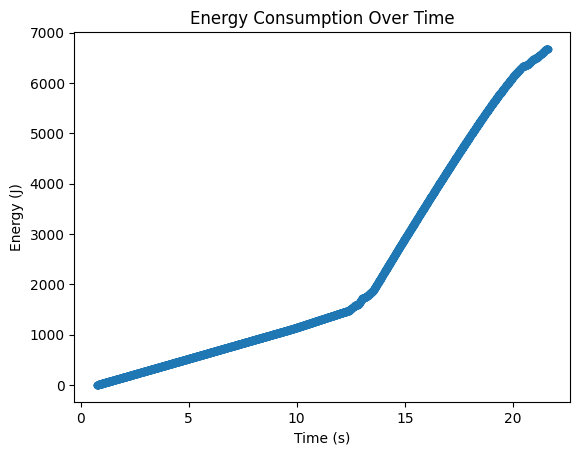

In [48]:
# Graph the energy over time for each GPU
y = ensemble.runs[0].nodes[0].metrics["A2amd_smi:::energy_consumed:device=0"]
# print(y.values)
# Graph the values against the timestamps to see energy over time
df = ak.DataFrame({
    "Timestamp": y.times,
    "Energy (J)": y.values
})

# Subtract the initial energy value from all energy values to get energy relative to start of run
df = df.to_pandas()
initial_energy = df["Energy (J)"][0]
df["Energy (J)"] = df["Energy (J)"] - initial_energy
# # Clamp negative values to 0
# # Print the timestamps of values that are negative before clamping
# negative_energy_timestamps = df[df["Energy (J)"] < 0]["Timestamp"]
# print("Negative energy values at timestamps (before clamping):")
# print(negative_energy_timestamps)
# df["Energy (J)"] = df["Energy (J)"].clip(lower=0)
# df.plot(x="Timestamp", y="Energy (J)", title="Energy Consumption Over Time", xlabel="Time (s)", ylabel="Energy (J)")
# Scatter plot
df.plot.scatter(x="Timestamp", y="Energy (J)", title="Energy Consumption Over Time", xlabel="Time (s)", ylabel="Energy (J)")

<Axes: title={'center': 'Power Violations Over Time'}, xlabel='Time (s)', ylabel='Violations'>

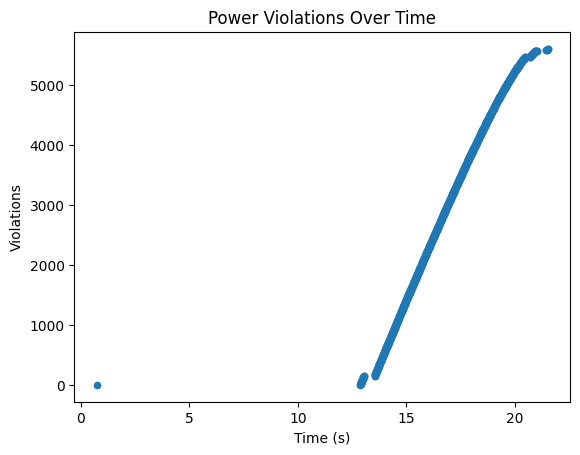

In [49]:
# Graph the energy over time for each GPU
y = ensemble.runs[0].nodes[0].metrics["A2amd_smi:::ppt_pwr_violation_acc:device=0"]
# print(y.values)
# Graph the values against the timestamps to see energy over time
df = ak.DataFrame({
    "Timestamp": y.times,
    "Violations": y.values
})

# Subtract the initial energy value from all energy values to get energy relative to start of run
df = df.to_pandas()
initial_energy = df["Violations"][0]
df["Violations"] = df["Violations"] - initial_energy
# # Clamp negative values to 0
# # Print the timestamps of values that are negative before clamping
# negative_energy_timestamps = df[df["Energy (J)"] < 0]["Timestamp"]
# print("Negative energy values at timestamps (before clamping):")
# print(negative_energy_timestamps)
# df["Energy (J)"] = df["Energy (J)"].clip(lower=0)
# df.plot(x="Timestamp", y="Energy (J)", title="Energy Consumption Over Time", xlabel="Time (s)", ylabel="Energy (J)")
# Scatter plot
df.plot.scatter(x="Timestamp", y="Violations", title="Power Violations Over Time", xlabel="Time (s)", ylabel="Violations")

In [50]:
# 2. Get Average Power from Cumulative Energy Metric (using 'rate')
df_energy_rate = ak.DataFrame.concat([
    ensemble.attribute(
        metric,
        topology_resolver=my_hpc_topology,
        output_mode='rate',
        strategy='exclusive'
    ) for metric in ["A2amd_smi:::energy_consumed:device=0"]
])
avg_energy_rate = df_energy_rate['Value'].mean()
print(f"Average Power (from Energy Metric): {avg_energy_rate:.2f} W")

Attributing 'A2amd_smi:::energy_consumed:device=0' on Arkouda Server...


100%|██████████| 1/1 [00:02<00:00,  2.30s/it]

Average Power (from Energy Metric): 322.65 W


In [51]:
df_joules = ak.DataFrame.concat([
    ensemble.attribute(
        metric,
        topology_resolver=my_hpc_topology,
        strategy='exclusive'
    ) for metric in ["A2amd_smi:::energy_consumed:device=0"]
])
print("Attribution complete.")

Attributing 'A2amd_smi:::energy_consumed:device=0' on Arkouda Server...


100%|██████████| 1/1 [00:02<00:00,  2.33s/it]

Attribution complete.


In [52]:
df_violations = ak.DataFrame.concat([
    ensemble.attribute(
        metric,
        topology_resolver=my_hpc_topology,
        strategy='exclusive'
    ) for metric in ["A2amd_smi:::ppt_pwr_violation_acc:device=0"]
])
print("Attribution complete.")

Attributing 'A2amd_smi:::ppt_pwr_violation_acc:device=0' on Arkouda Server...


100%|██████████| 1/1 [00:02<00:00,  2.26s/it]

Attribution complete.


In [53]:
df_violations_rate = ak.DataFrame.concat([
    ensemble.attribute(
        metric,
        topology_resolver=my_hpc_topology,
        strategy='exclusive',
        output_mode='rate',
    ) for metric in ["A2amd_smi:::ppt_pwr_violation_acc:device=0"]
])
print("Attribution complete.")

Attributing 'A2amd_smi:::ppt_pwr_violation_acc:device=0' on Arkouda Server...


100%|██████████| 1/1 [00:02<00:00,  2.31s/it]

Attribution complete.


Profiling time on Arkouda Server...


100%|██████████| 1/1 [00:02<00:00,  2.11s/it]


This transfer will use 76 MB .
This transfer will use 76 MB .


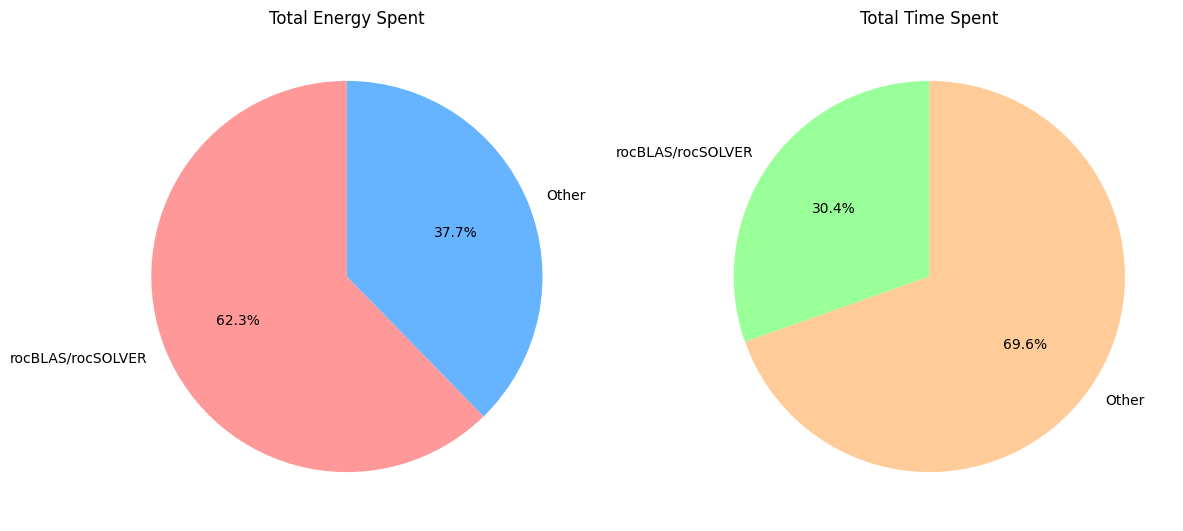

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

time_profile = ensemble.time_profile(topology_resolver=my_hpc_topology, strategy='exclusive')

# Get the total time spent in ROCBLAS or ROCSOLVER
time_profile_pd = time_profile.to_pandas()
time_mask = time_profile_pd['Name'].str.contains('rocblas|rocsolver', case=False)
total_time = time_profile_pd['Value'].sum()
time_in_rocblas = time_profile_pd[time_mask]['Value'].sum()
other_time = total_time - time_in_rocblas

# Do the same for energy
energy_pd = df_joules.to_pandas()
energy_mask = energy_pd['Name'].str.contains('rocblas|rocsolver', case=False)
total_energy = energy_pd['Value'].sum()
energy_in_rocblas = energy_pd[energy_mask]['Value'].sum()
other_energy = total_energy - energy_in_rocblas

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.pie([energy_in_rocblas, other_energy], labels=['rocBLAS/rocSOLVER', 'Other'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
ax1.set_title('Total Energy Spent')

ax2.pie([time_in_rocblas, other_time], labels=['rocBLAS/rocSOLVER', 'Other'], autopct='%1.1f%%', startangle=90, colors=['#99ff99','#ffcc99'])
ax2.set_title('Total Time Spent')

plt.tight_layout()
plt.show()


Profiling time on Arkouda Server...


100%|██████████| 1/1 [00:02<00:00,  2.17s/it]


This transfer will use 76 MB .
This transfer will use 76 MB .


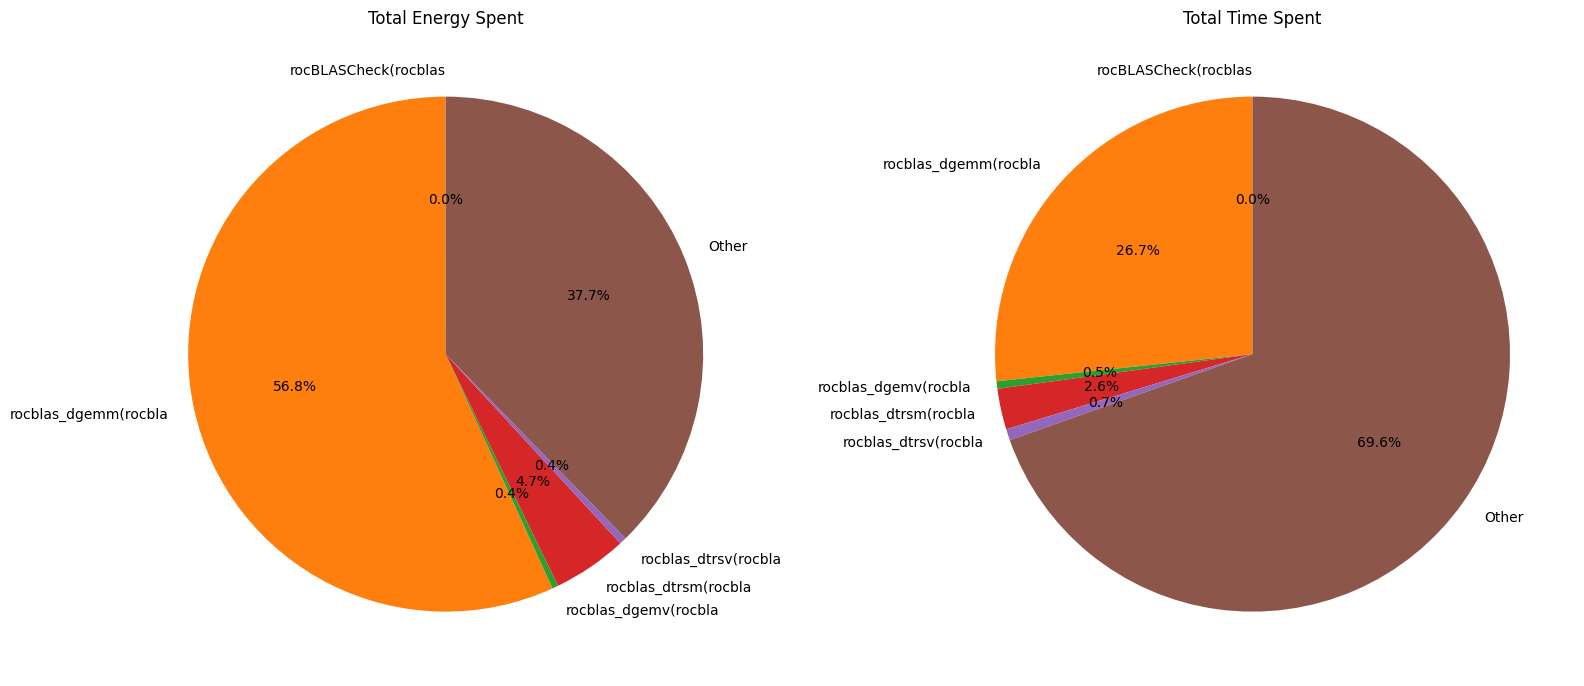

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

time_profile = ensemble.time_profile(topology_resolver=my_hpc_topology, strategy='exclusive')
time_profile_pd = time_profile.to_pandas()
energy_pd = df_joules.to_pandas()

def get_pie_data(df, pattern):
    mask = df['Name'].str.contains(pattern, case=False)
    roc_data = df[mask].groupby('Name')['Value'].sum()
    other_val = df[~mask]['Value'].sum()
    return pd.concat([roc_data, pd.Series({'Other': other_val})])

time_data = get_pie_data(time_profile_pd, 'rocblas|rocsolver')
energy_data = get_pie_data(energy_pd, 'rocblas|rocsolver')

# Trim all the names to be 20 characters long
energy_data.index = energy_data.index.str[:20]
time_data.index = time_data.index.str[:20]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.pie(energy_data, labels=energy_data.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Total Energy Spent')

ax2.pie(time_data, labels=time_data.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Total Time Spent')

plt.tight_layout()
plt.show()


In [56]:
display(df_joules.sort_values(by="Value", ascending=False).head(20).to_pandas())

,Start Time,End Time,Name,Depth,Value,Rank,Node,Run
0,0.785132,9.825482,HPL_InitGPU(HPL_S_grid const*),2,1113.150579,MPI Rank 0,Node0,new-plugin10
1,9.825936,12.416464,"HPL_pdmatgen(HPL_S_test*, HPL_S_grid*, HPL_S_palg*, HPL_S_pma...",3,354.080255,MPI Rank 0,Node0,new-plugin10
2,9.825698,21.611786,"HPL_pdtest(HPL_S_test*, HPL_S_grid*, HPL_S_palg*, int, int)",2,244.502084,MPI Rank 0,Node0,new-plugin10
3,12.416536,13.221968,"HPL_pdwarmup(HPL_S_test*, HPL_S_grid*, HPL_S_palg*, HPL_S_pmat*)",3,106.077151,MPI Rank 0,Node0,new-plugin10
4,13.537643,13.610345,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,54.144301,MPI Rank 0,Node0,new-plugin10
5,12.960058,13.032613,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,53.353699,MPI Rank 0,Node0,new-plugin10
6,13.623834,13.695518,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,53.180480,MPI Rank 0,Node0,new-plugin10
7,12.874838,12.947094,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,53.101137,MPI Rank 0,Node0,new-plugin10
8,13.793749,13.864369,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,52.300130,MPI Rank 0,Node0,new-plugin10
9,13.708684,13.780542,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,52.243251,MPI Rank 0,Node0,new-plugin10


This transfer will use 76 MB .


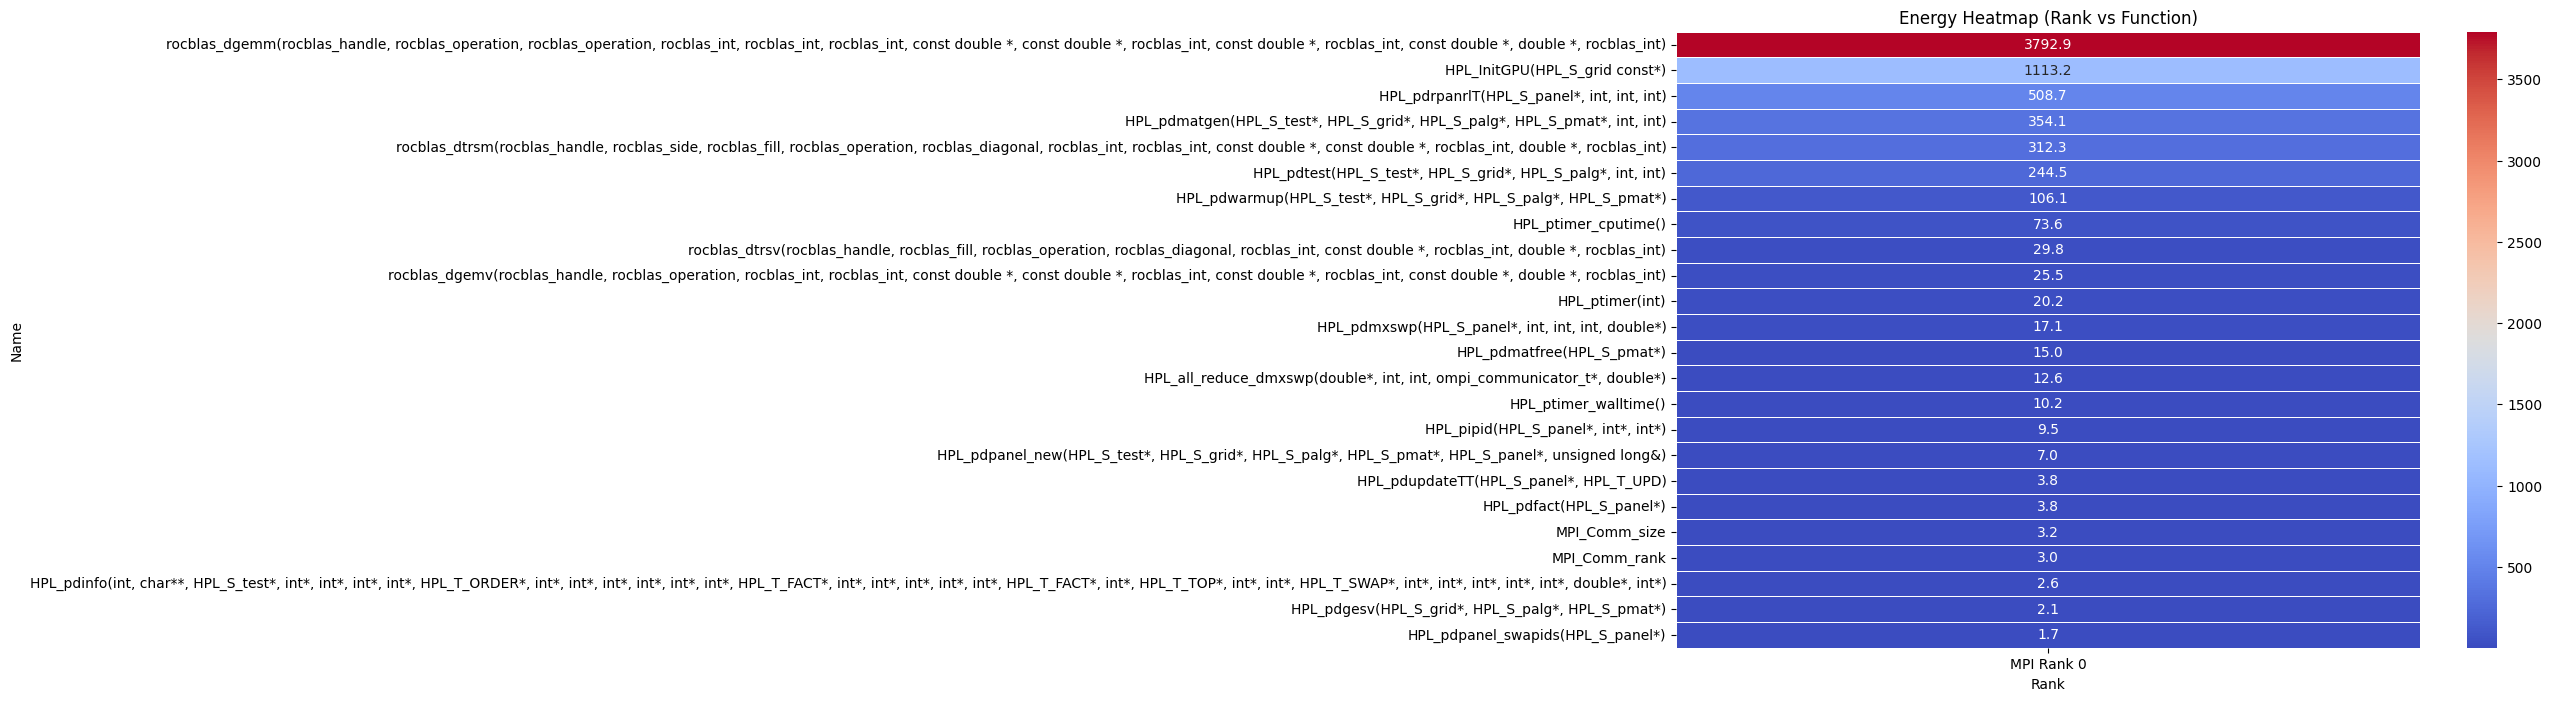

In [57]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_joules, "Energy Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='sum')

This transfer will use 76 MB .


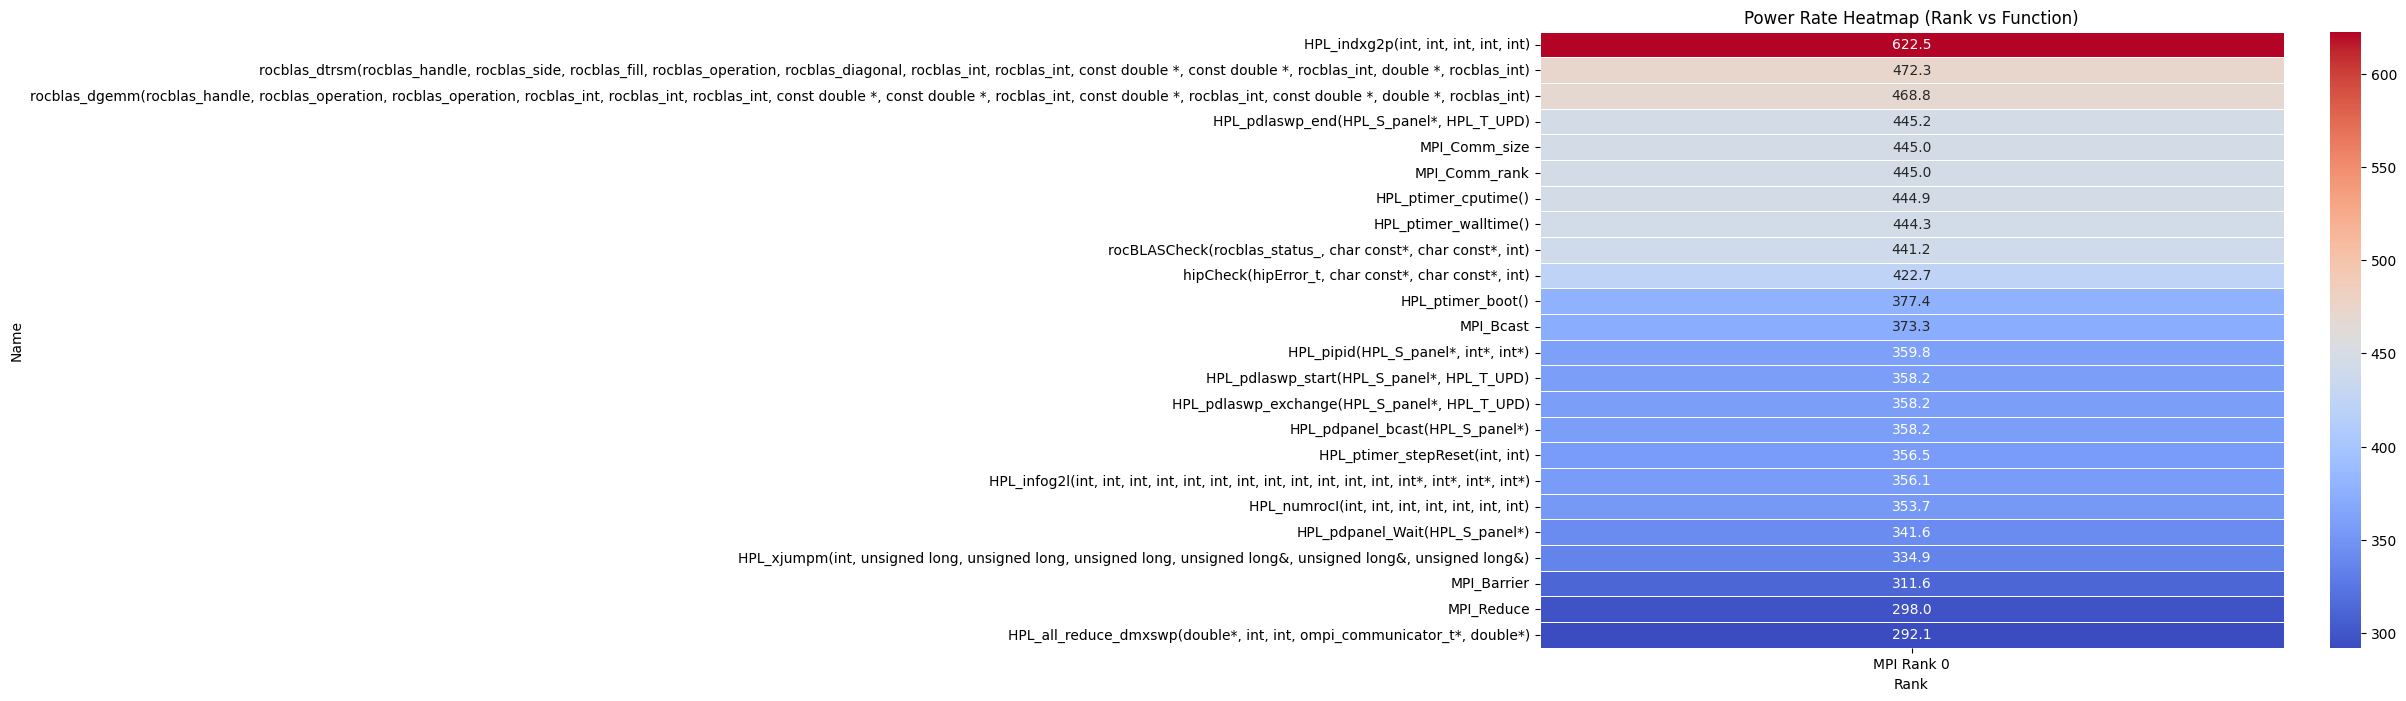

In [58]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_energy_rate, "Power Rate Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='mean')

In [59]:
# Visualize Flamegraph for Rank 0
print("Generating Flamegraph...")
Visualizer.plot_flamegraph(
    df_joules, 
    rank_filter="MPI Rank 0", 
    metric_name="Joules"
)

Generating Flamegraph...
This transfer will use 76 MB .
Rendering 1228 events using Optimized Rectangles...
Downsampled to 1002 visual elements (Manageable for SVG)


In [60]:
# Visualize Node View (Metrics + Flamegraphs)
print("Generating Node View...")
run = ensemble.runs[0]
node_metrics = run.nodes[0].metrics
metrics_to_plot = [m for name, m in node_metrics.items() if "energy" in name]

Visualizer.plot_node_view(
    attributed_df=df_joules,
    ranks=["MPI Rank 0", "MPI Rank 1"],
    metrics_data=metrics_to_plot,
    title="Node 0 Analysis: Power Lines vs Function Execution"
)

Generating Node View...
This transfer will use 76 MB .
Plotting metrics...


In [61]:
# # 2. Get Average Power from Cumulative Energy Metric (using 'rate')
# df_energy_rate = ak.DataFrame.concat([
#     ensemble.attribute(
#         metric,
#         topology_resolver=my_hpc_topology,
#         output_mode='rate',
#         strategy='exclusive'
#     ) for metric in ["A2rocm_smi:::energy_count:device=0", "A2rocm_smi:::energy_count:device=2", "A2rocm_smi:::energy_count:device=4", "A2rocm_smi:::energy_count:device=6"]
# ])
# avg_energy_rate = df_energy_rate['Value'].mean()
# print(f"Average Power (from Energy Metric): {avg_energy_rate:.2f} W")

In [62]:
# # Visualize Distribution
# Visualizer.plot_distribution(df_energy_rate, "Power Distribution (Device 0)", bins=50)

This transfer will use 76 MB .


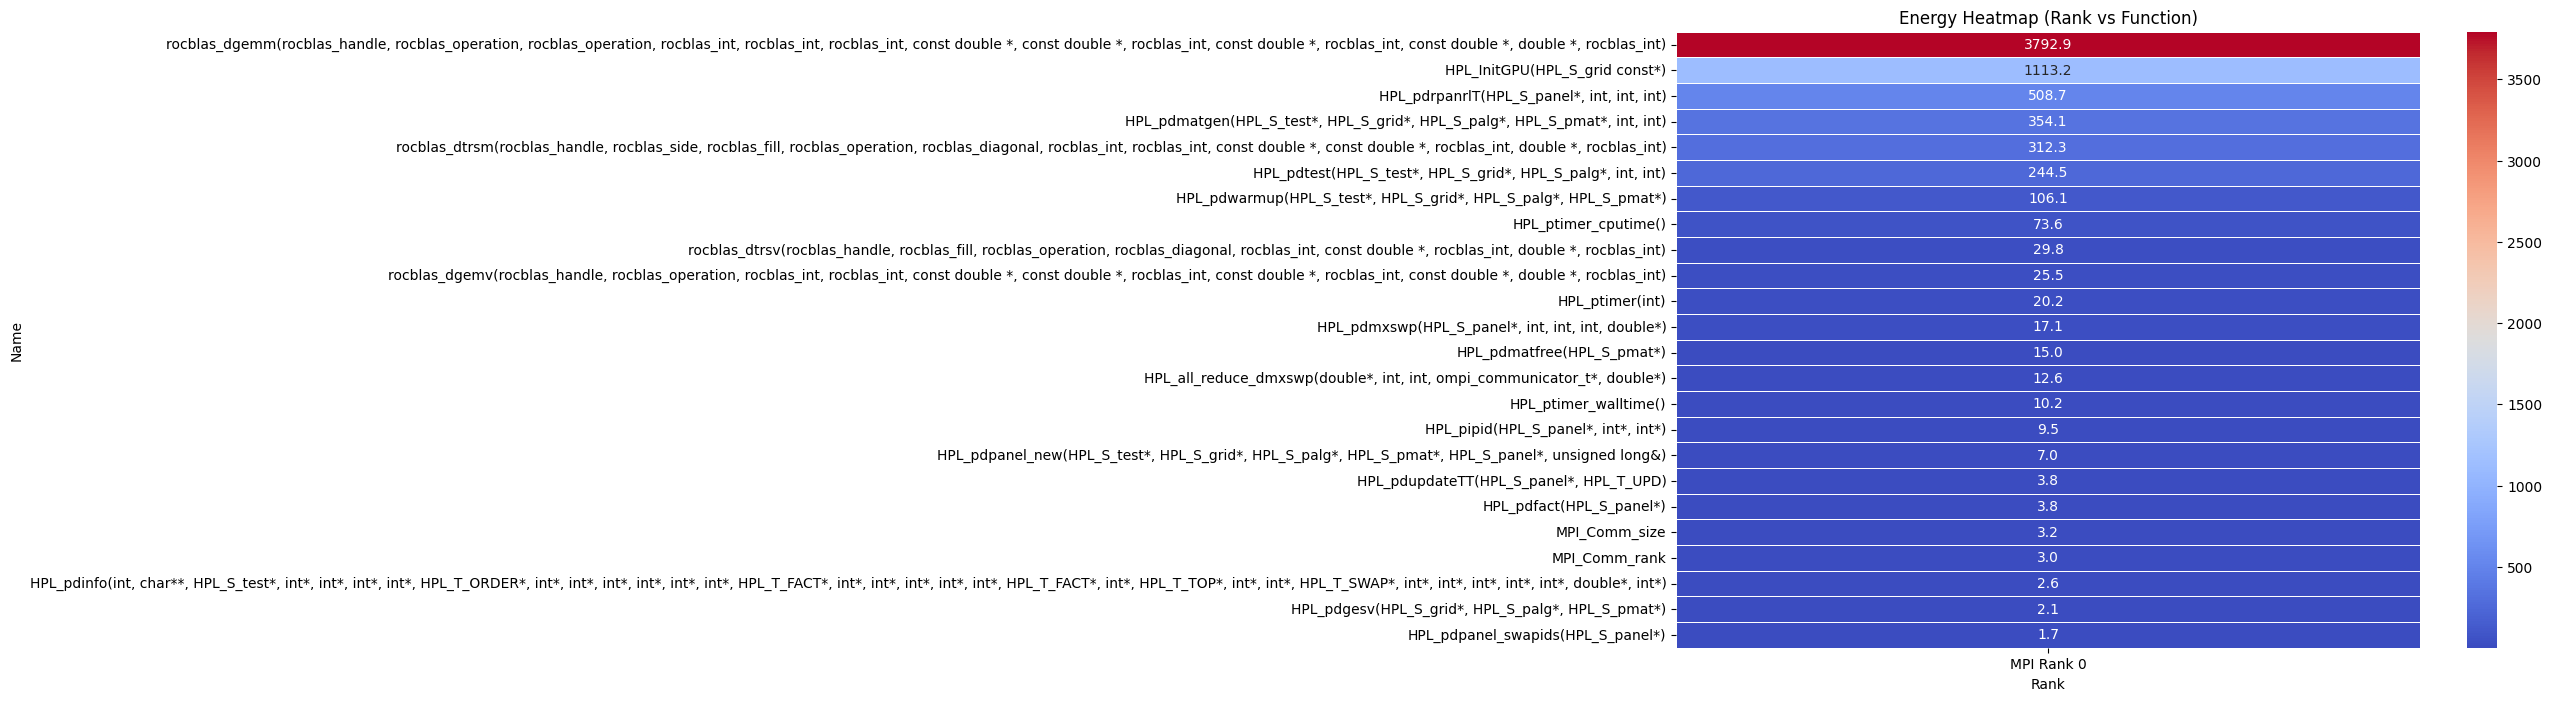

In [63]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_joules, "Energy Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='sum')

This transfer will use 76 MB .


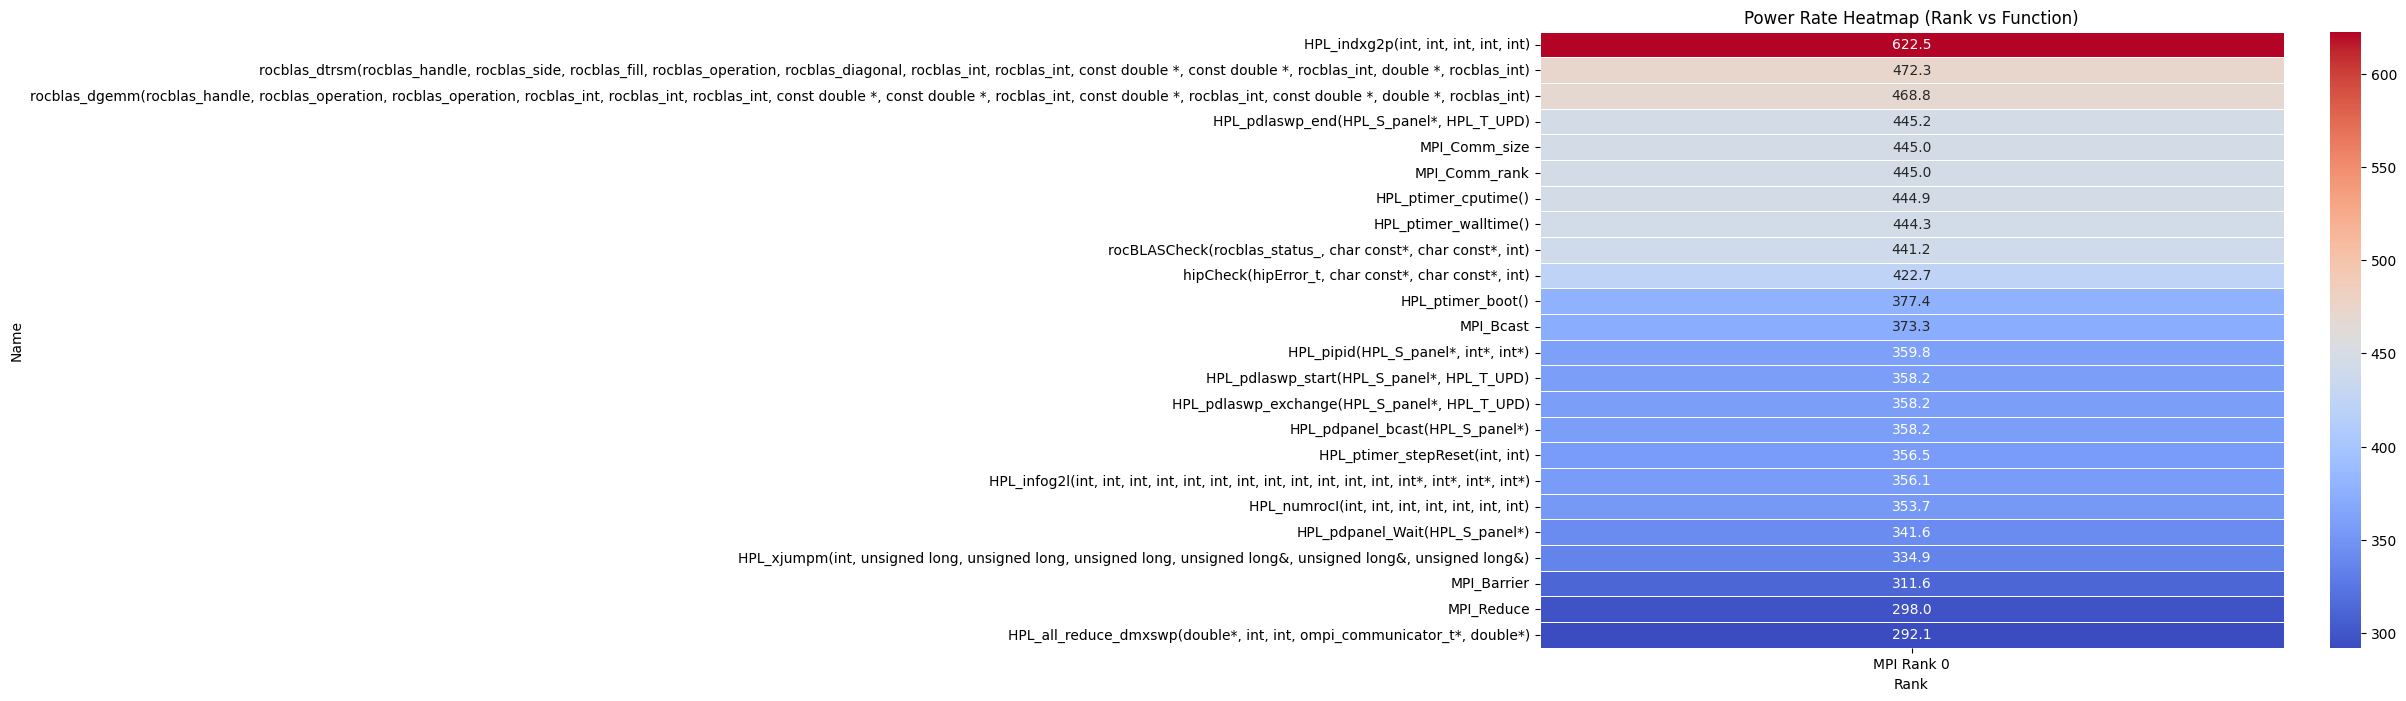

In [64]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_energy_rate, "Power Rate Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='mean')

This transfer will use 76 MB .


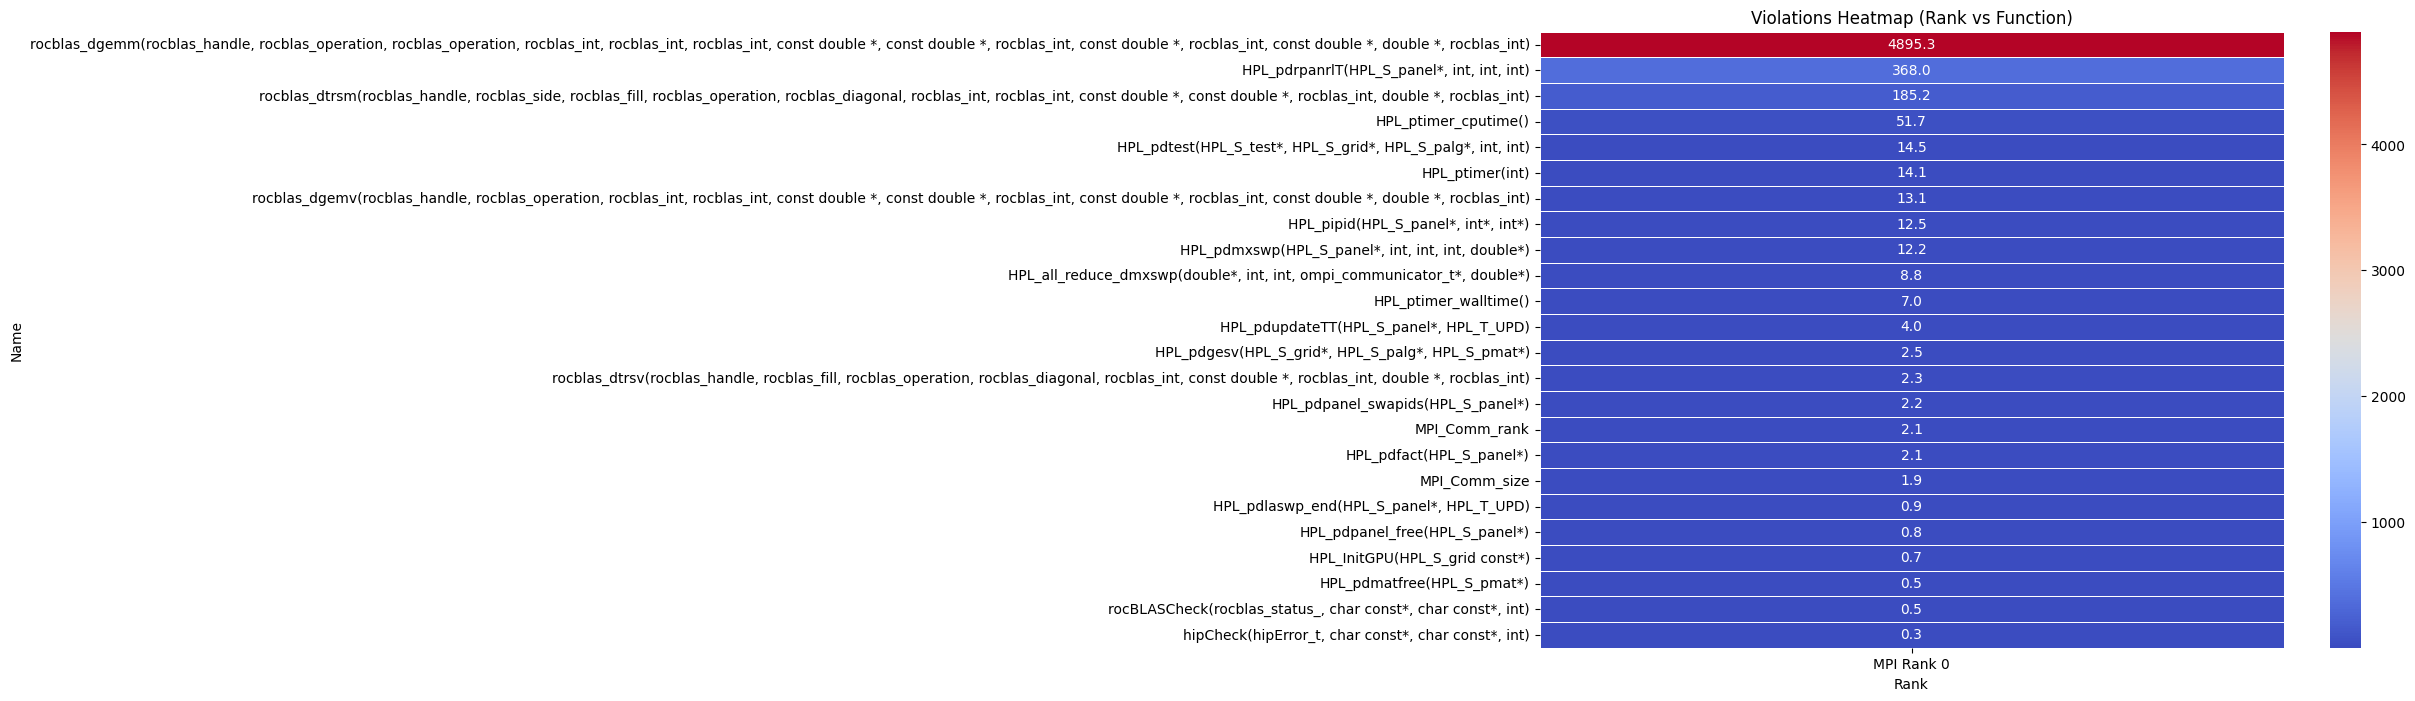

In [65]:
# Visualize Heatmap of Rates
Visualizer.plot_heatmap(df_violations, "Violations Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='sum')

This transfer will use 76 MB .


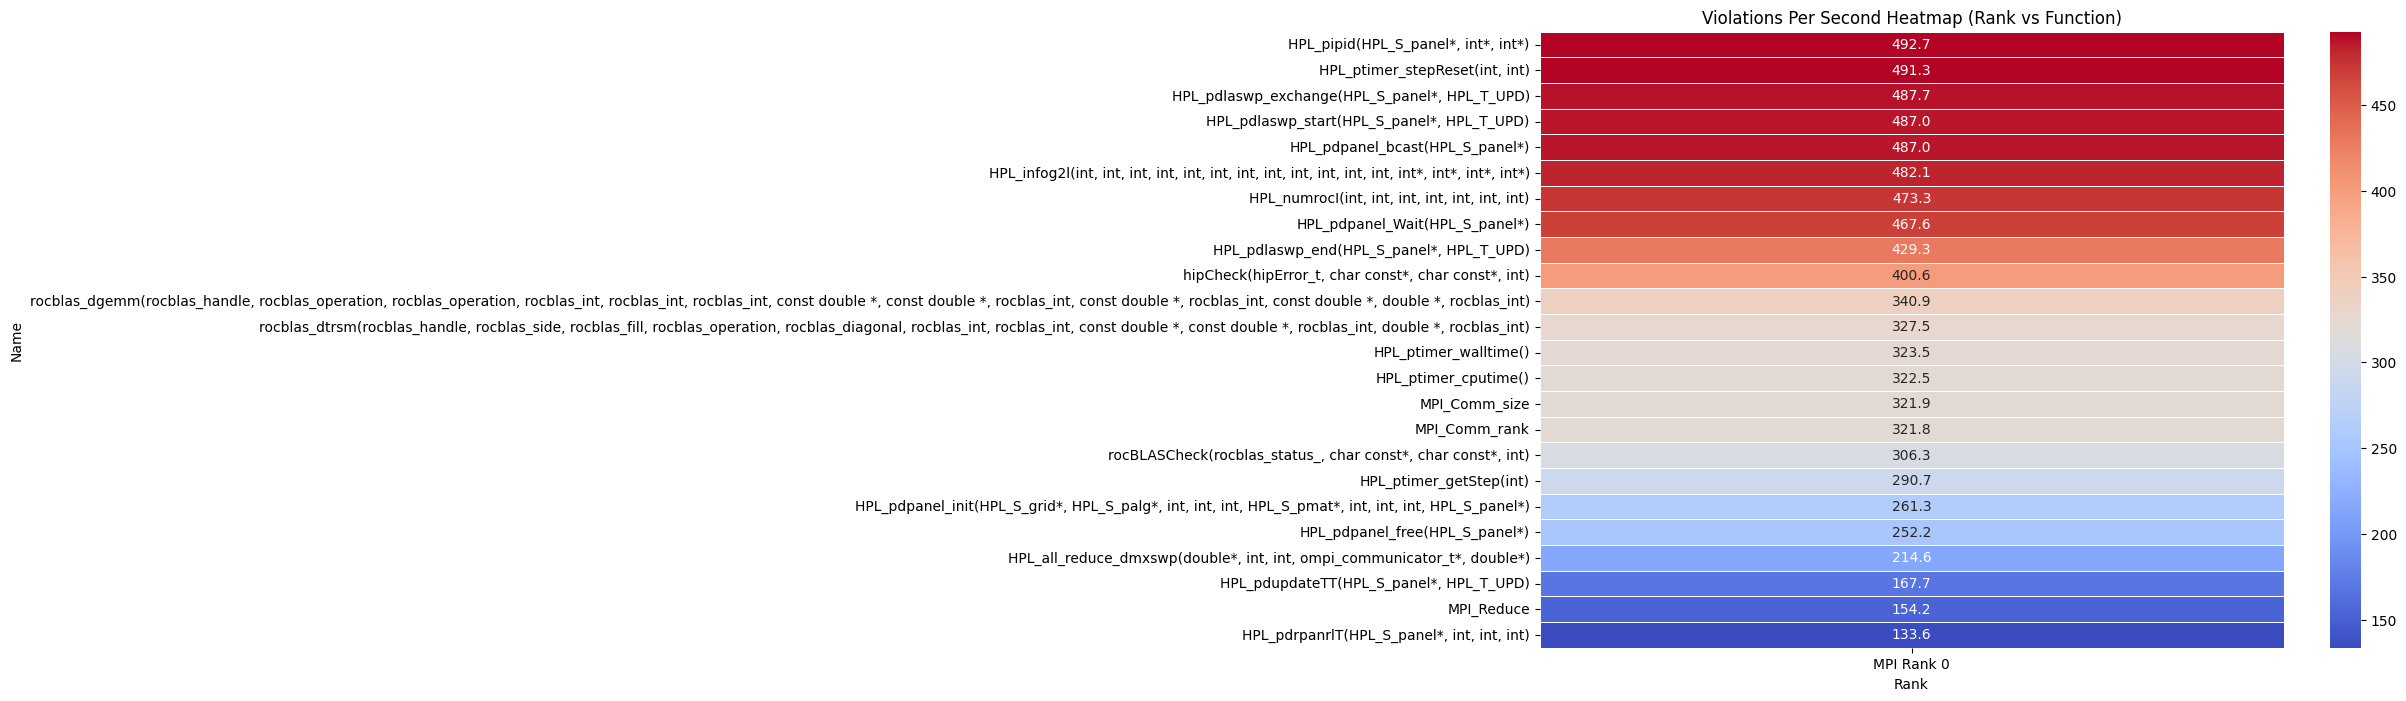

In [66]:
Visualizer.plot_heatmap(df_violations_rate, "Violations Per Second Heatmap (Rank vs Function)", cmap='coolwarm', top_n=24, aggregation_func='mean')


In [75]:
# Find top 5 calls with highest power. Do not group by name
power_by_function = df_energy_rate.sort_values(by="Value", ascending=False)
power_by_function = power_by_function[power_by_function["End Time"] - power_by_function["Start Time"] > 0.005]
display(power_by_function.to_pandas())

# Take the top one
top_function = power_by_function.to_pandas().iloc[0]

# Identify which Nth call this is of that function
same_function_calls = df_energy_rate[df_energy_rate["Name"] == top_function["Name"]].to_pandas()
same_function_calls = same_function_calls.sort_values(by="Start Time")
same_function_calls = same_function_calls.reset_index(drop=True)
call_index = same_function_calls[same_function_calls["Start Time"] == top_function["Start Time"]].index[0]
print(f"The top power-consuming call is the {call_index}th call of function {top_function['Name']}")



,Start Time,End Time,Name,Depth,Value,Rank,Node,Run
0,16.131927,16.182105,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,917.421084,MPI Rank 0,Node0,new-plugin10
1,13.537643,13.610345,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,744.747294,MPI Rank 0,Node0,new-plugin10
2,13.623834,13.695518,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,741.872813,MPI Rank 0,Node0,new-plugin10
3,15.874393,15.926681,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,740.631487,MPI Rank 0,Node0,new-plugin10
4,13.793749,13.864369,"rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_oper...",5,740.586700,MPI Rank 0,Node0,new-plugin10
...,...,...,...,...,...,...,...,...
790,12.718126,12.869924,"HPL_pdrpanrlT(HPL_S_panel*, int, int, int)",5,0.003980,MPI Rank 0,Node0,new-plugin10
791,20.456016,20.664032,"HPL_pdrpanrlT(HPL_S_panel*, int, int, int)",7,0.002355,MPI Rank 0,Node0,new-plugin10
792,12.718126,12.855673,"HPL_pdrpanrlT(HPL_S_panel*, int, int, int)",7,0.001557,MPI Rank 0,Node0,new-plugin10
793,20.450691,20.664033,"HPL_pdrpanrlT(HPL_S_panel*, int, int, int)",5,0.001346,MPI Rank 0,Node0,new-plugin10


This transfer will use 1 MB .
The top power-consuming call is the 933th call of function rocblas_dgemm(rocblas_handle, rocblas_operation, rocblas_operation, rocblas_int, rocblas_int, rocblas_int, const double *, const double *, rocblas_int, const double *, rocblas_int, const double *, double *, rocblas_int)


This transfer will use 76 MB .


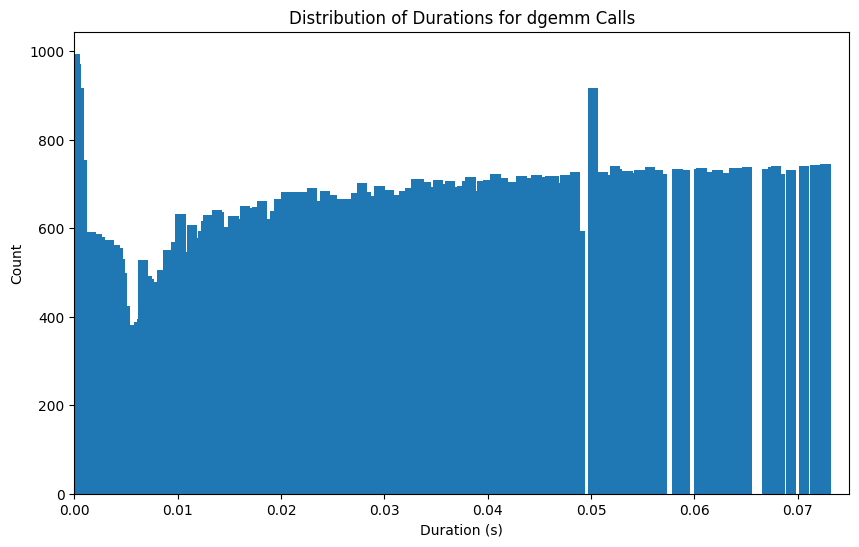

In [87]:
# Graph the distribution of durations for dgemm calls
dgemm_calls = df_energy_rate.to_pandas()
dgemm_calls = dgemm_calls[dgemm_calls["Name"].str.contains("dgemm", case=False)]
dgemm_calls["Duration"] = dgemm_calls["End Time"] - dgemm_calls["Start Time"]
# Show log scale on x-axis to better visualize distribution
# Set minor ticks to be increments of 0.001 seconds
plt.figure(figsize=(10, 6))
# plt.hist(dgemm_calls["Duration"], bins=50, log=True)
plt.title("Distribution of Durations for dgemm Calls")
plt.xlabel("Duration (s)")
plt.ylabel("Count")

# Make it a bar chart
plt.bar(dgemm_calls["Duration"], dgemm_calls["Value"], width=0.001)
# Set x-axis to show from 0 to 0.075 seconds
plt.xlim(0, 0.075)

plt.show()